In [1]:
import yfinance as yf #yahoo finance
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
stock_data=yf.download('AAPL',start='2025-01-01') #'AAPL' is the ticker for the apple data and we should know the ticker to import any company data
stock_data.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.525177,247.746654,240.506207,247.577564,55740700
2025-01-03,242.037827,242.853364,240.575812,242.037827,40244100
2025-01-06,243.668930,245.986273,241.878706,242.982676,45045600
2025-01-07,240.894089,244.215939,240.038760,241.659894,40856000
2025-01-08,241.381409,242.385931,238.745812,240.605648,37628900
2025-01-10,235.563202,238.855216,231.734113,238.706022,61710900
2025-01-13,233.126480,233.395017,228.471914,232.261212,49630700
2025-01-14,232.012558,234.837124,231.206961,233.474572,39435300


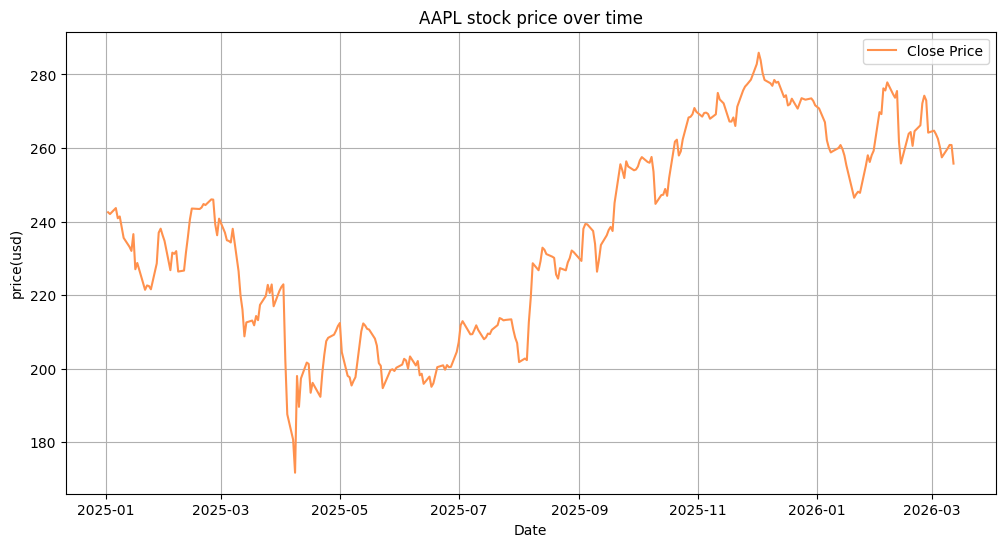

In [2]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index,stock_data['Close'],label='Close Price',color='#FF914D')#x axis values will be date because at index we have date column and at y axis we will have closing stock price
plt.title("AAPL stock price over time")
plt.xlabel("Date")
plt.ylabel("price(usd)")
plt.legend()
plt.grid(True)
plt.show()

##Classical time series decomposition

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition_additive=seasonal_decompose(stock_data['Close'],model='additive',period=30)

In [6]:
trend_additive=decomposition_additive.trend #the decomposition_additive varible store all the 3 componernts from that we are extracting only the trend component
seasonal_additive=decomposition_additive.seasonal
residual_additive=decomposition_additive.resid

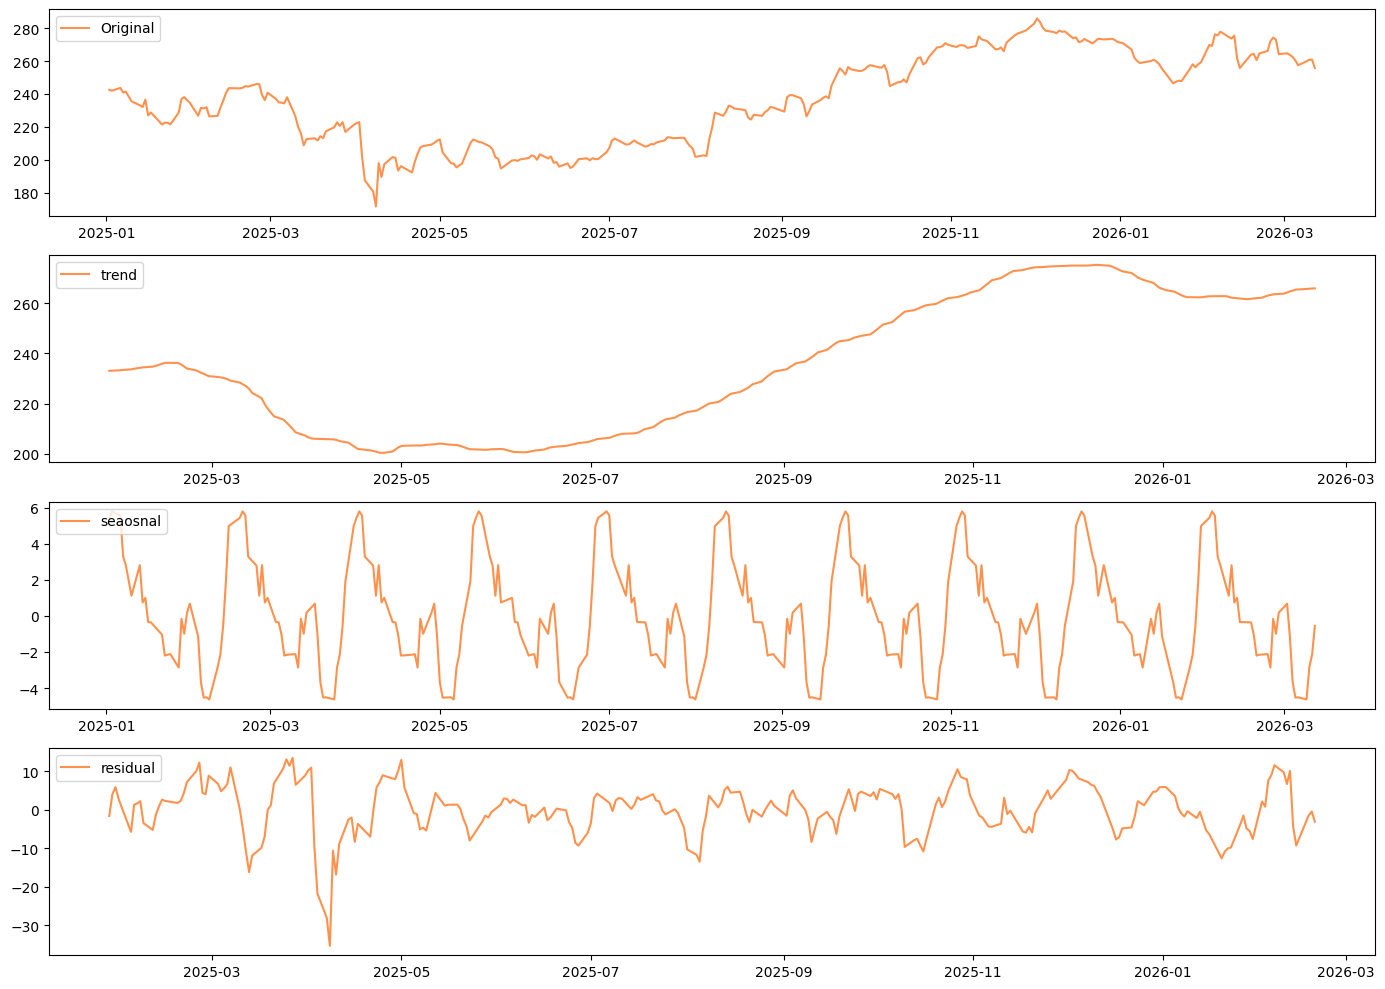

In [8]:
plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(stock_data['Close'],label='Original',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_additive,label='trend',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_additive,label='seaosnal',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_additive,label='residual',color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()





##STL Decomposition

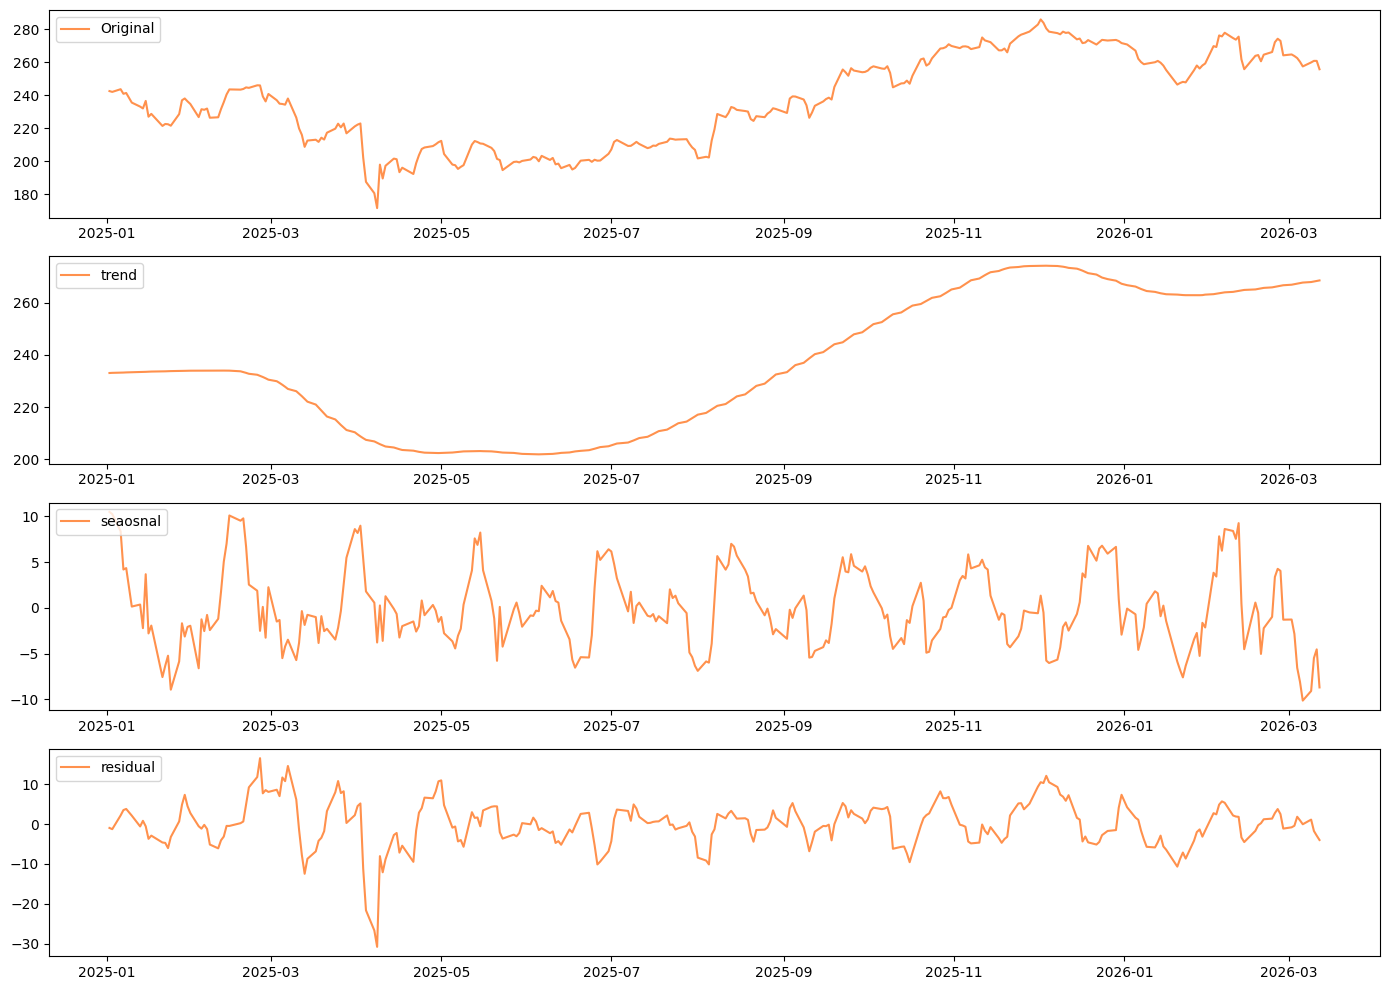

In [9]:
from statsmodels.tsa.seasonal import STL
stl=STL(stock_data['Close'],period=30)
result=stl.fit()

plt.figure(figsize=(14,10))
plt.subplot(411)
plt.plot(result.observed,label='Original',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend,label='trend',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal,label='seaosnal',color='#FF914D')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid,label='residual',color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()




